# Day 8: GPT Planner And Action Validation

Use an LLM-style structured planner without making online API calls. The lesson is that GPT proposes hypotheses and candidate actions; ChemWorld validates and tests them.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(8)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)


project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day08


In [2]:
tu.display_learning_goal(
    8,
    "Structured GPT planning",
    [
        "Write action proposals as strict JSON.",
        "Validate GPT-style suggestions before running experiments.",
        "Compare rationale with measured final-assay results.",
        "Separate language plausibility from experimental evidence.",
    ],
)

In [3]:
tu.display_api_card()

In [4]:
tu.display_student_checkpoint(
    8,
    [
        "a validated JSON action list",
        "one rejected or repaired proposal",
        "one bar chart of proposal scores",
        "one note on how GPT was constrained",
    ],
)

In [5]:
gpt_prompt = {
    "system": "You propose virtual ChemWorld reaction experiments as strict JSON only.",
    "task": "Suggest five recipes that balance yield, safety risk, and degradation.",
    "schema": {
        "temperature": "degC in [40, 160]",
        "time": "h in [0.25, 8.0]",
        "initial_concentration": "mol/L in [0.10, 2.00]",
        "stirring_speed": "rpm in [100, 1200]",
        "catalyst": "integer 0..3",
        "solvent": "integer 0..3",
        "rationale": "short chemical reason",
    },
}
tu.show_json_panel("GPT planner prompt contract", gpt_prompt)

In [6]:
from chemworld.core.actions import canonicalize_action

raw_gpt_proposals = [
    {
        "temperature": 72,
        "time": 0.55,
        "initial_concentration": 0.32,
        "stirring_speed": 650,
        "catalyst": 1,
        "solvent": 1,
        "rationale": "moderate heat with lower risk solvent",
    },
    {
        "temperature": 95,
        "time": 0.40,
        "initial_concentration": 0.42,
        "stirring_speed": 760,
        "catalyst": 1,
        "solvent": 2,
        "rationale": "faster target reaction, watch degradation",
    },
    {
        "temperature": 145,
        "time": 0.90,
        "initial_concentration": 0.90,
        "stirring_speed": 1300,
        "catalyst": 7,
        "solvent": 3,
        "rationale": "invalid stress test from an overconfident planner",
    },
    {
        "temperature": 58,
        "time": 0.85,
        "initial_concentration": 0.28,
        "stirring_speed": 550,
        "catalyst": 0,
        "solvent": 0,
        "rationale": "slow safer run to test degradation",
    },
    {
        "temperature": 105,
        "time": 0.25,
        "initial_concentration": 0.50,
        "stirring_speed": 820,
        "catalyst": 3,
        "solvent": 1,
        "rationale": "short hot run to trade conversion against degradation",
    },
]

validated = []
for proposal_id, proposal in enumerate(raw_gpt_proposals, start=1):
    action = {key: value for key, value in proposal.items() if key != "rationale"}
    fixed = canonicalize_action(action)
    validated.append(
        {
            "proposal": f"p{proposal_id}",
            "recipe": fixed,
            **tu.format_recipe(fixed),
            "changed_by_validator": fixed != action,
            "rationale": proposal["rationale"],
        }
    )
validated_df = pd.DataFrame(validated)
cols = [
    "proposal",
    "temperature_C",
    "time_h",
    "initial_concentration_M",
    "catalyst",
    "solvent",
    "changed_by_validator",
    "rationale",
]
display(validated_df[cols])


,proposal,temperature_C,time_h,initial_concentration_M,catalyst,solvent,changed_by_validator,rationale
0,p1,72.0,0.55,0.32,cat_b,ethanol,False,moderate heat with lower risk solvent
1,p2,95.0,0.40,0.42,cat_b,acetonitrile,False,"faster target reaction, watch degradation"
2,p3,145.0,0.90,0.90,cat_d,toluene,True,invalid stress test from an overconfident planner
3,p4,58.0,0.85,0.28,cat_a,water,False,slow safer run to test degradation
4,p5,105.0,0.25,0.50,cat_d,ethanol,False,short hot run to trade conversion against degr...


,proposal,yield,degradation,risk,score,changed_by_validator,rationale
0,p1,0.7731,0.0467,0.0811,0.6043,False,moderate heat with lower risk solvent
1,p2,0.7224,0.1117,0.1225,0.5530,False,"faster target reaction, watch degradation"
2,p4,0.6576,0.0258,0.0518,0.5393,False,slow safer run to test degradation
3,p5,0.6033,0.0506,0.1307,0.4592,False,short hot run to trade conversion against degr...
4,p3,0.0860,0.5867,0.4220,0.0000,True,invalid stress test from an overconfident planner


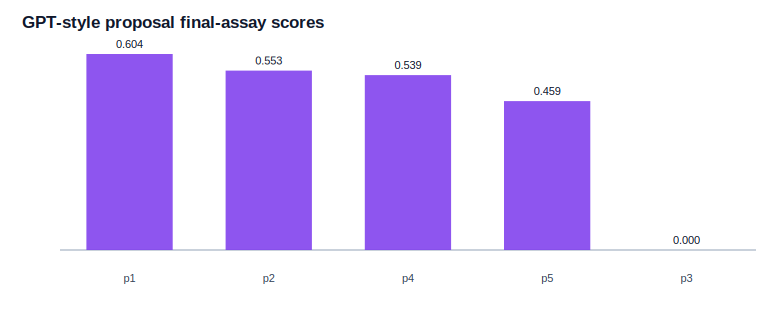

In [7]:
results = []
for row in validated:
    result = tu.run_recipe(row["recipe"], split="public-test", seed=810)
    result["proposal"] = row["proposal"]
    result["changed_by_validator"] = row["changed_by_validator"]
    result["rationale"] = row["rationale"]
    results.append(result)
result_df = pd.DataFrame(results).sort_values("score", ascending=False).reset_index(drop=True)
display(
    result_df[
        ["proposal", "yield", "degradation", "risk", "score", "changed_by_validator", "rationale"]
    ]
)
display(
    tu.bar_svg(
        result_df["proposal"].tolist(),
        result_df["score"].astype(float).tolist(),
        title="GPT-style proposal final-assay scores",
        color="#7c3aed",
    )
)

In [8]:
best = result_df.iloc[0]
feedback_prompt = {
    "observed_best": {
        "proposal": best["proposal"],
        "score": float(best["score"]),
        "yield": float(best["yield"]),
        "risk": float(best["risk"]),
    },
    "instruction": (
        "Propose three local variations near the best condition, "
        "but reduce risk and degradation."
    ),
    "guardrail": "All outputs must pass canonicalize_action before execution.",
}
tu.show_json_panel("Feedback prompt for a next GPT planning round", feedback_prompt)
